# Week 7 - Milestone One week

# 1. Lesson: no lesson this week.  Milestone One is due!

# 2. Weekly graph question

Below are the graphs from last week's weekly graph question.  Suppose you wanted to cause the viewer to examine the last three months of data first.  How could you use preattentive attributes to do that?  Suggest several possibilities.

In [2]:
import numpy as np
import seaborn as sns
import pandas as pd

/tmp/ipykernel_8341/2149468501.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

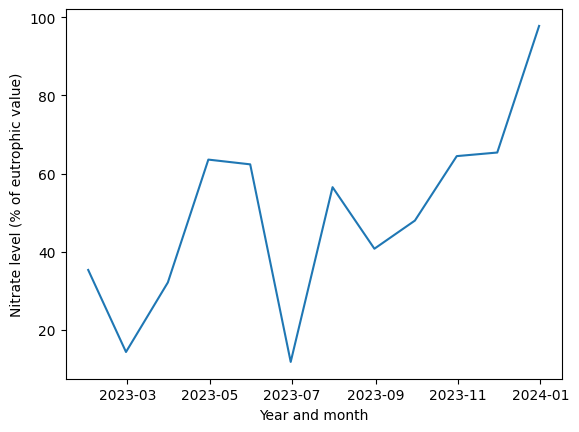

In [3]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

/tmp/ipykernel_8341/1012779568.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

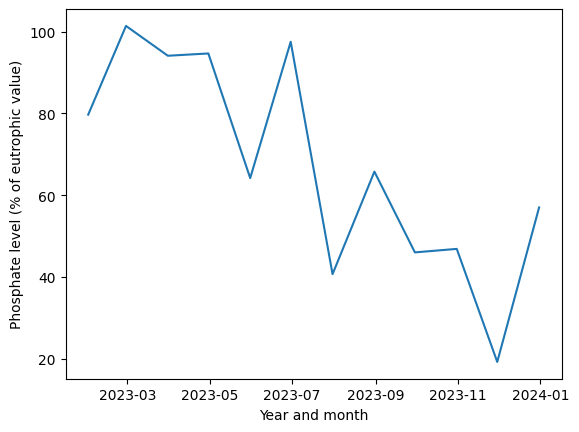

In [4]:
np.random.seed(1)
time_series = 100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

# 3. Working on your datasets

This week, you can work on Milestone One rather than having a particular exercise about working on your datasets

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 99-119 of the Storytelling With Data book as best you can. (The first half of chapter four). You do not have to get the exact data values right, just the overall look and feel.

In [6]:
# ---------------------------
# Load Kaggle Dataset into a DataFrame
# ---------------------------

import os
import pandas as pd
import kagglehub

# 1. Download the dataset from Kaggle
dataset_path = kagglehub.dataset_download("ammaraahmad/us-ecommerce-record-2020")
print("Dataset downloaded to:", dataset_path)

# 2. Find the CSV file inside the extracted folder
csv_files = [f for f in os.listdir(dataset_path) if f.endswith('.csv')]
if len(csv_files) == 0:
    raise FileNotFoundError("No CSV file found in the dataset folder!")
csv_file = os.path.join(dataset_path, csv_files[0])
print("CSV file detected:", csv_file)

# 3. Load the CSV into a pandas DataFrame
df = pd.read_csv(csv_file, encoding='ISO-8859-1')

# 4. Quick check
print("Dataset loaded successfully!")
print("Shape:", df.shape)
print(df.head())

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset downloaded to: /home/codespace/.cache/kagglehub/datasets/ammaraahmad/us-ecommerce-record-2020/versions/1
CSV file detected: /home/codespace/.cache/kagglehub/datasets/ammaraahmad/us-ecommerce-record-2020/versions/1/US  E-commerce records 2020.csv
Dataset loaded successfully!
Shape: (3312, 19)
  Order Date  Row ID        Order ID       Ship Mode Customer ID      Segment  \
0   01-01-20     849  CA-2017-107503  Standard Class    GA-14725     Consumer   
1   01-01-20    4010  CA-2017-144463  Standard Class    SC-20725     Consumer   
2   01-01-20    6683  CA-2017-154466     First Class    DP-13390  Home Office   
3   01-01-20    8070  CA-2017-151750  Standard Class    JM-15250     Consumer   
4   01-01-20    8071  CA-2017-151750  Standard Class    JM-15250     Consumer   

         Country         City       State  Postal Code   Region  \
0  United States       Lorain        Ohio        44052     East   
1  United States  Los Angeles  California        90036     West   
2  United S

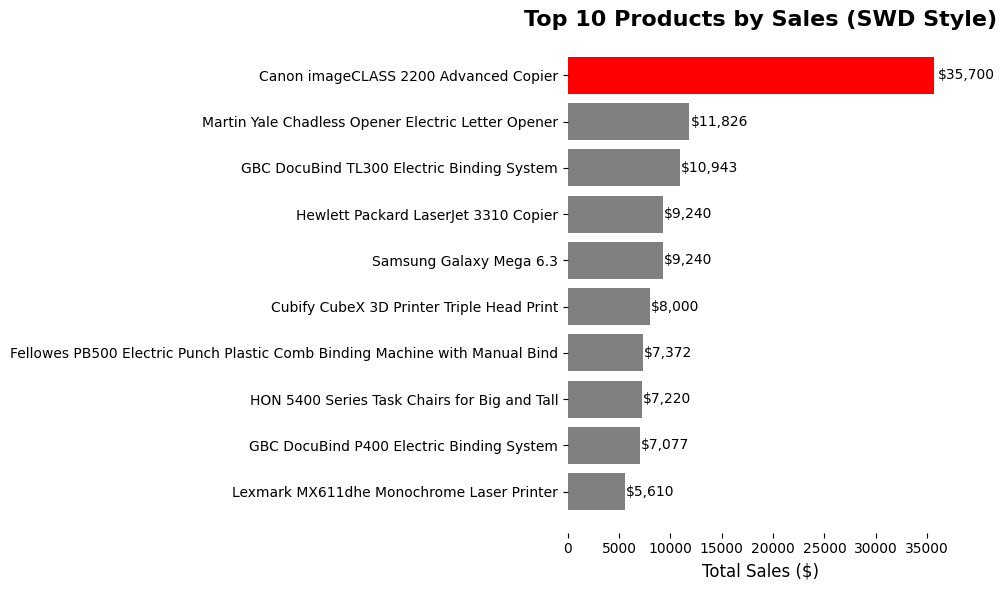

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Aggregate total sales by product
top_products = df.groupby('Product Name')['Sales'].sum().reset_index()

# Sort descending and take top 10
top_products = top_products.sort_values(by='Sales', ascending=False).head(10)

# Set colors: highlight top product
colors = ['red' if i == 0 else 'gray' for i in range(len(top_products))]

# SWD-style horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(top_products['Product Name'], top_products['Sales'], color=colors)
plt.gca().invert_yaxis()  # Highest at top

# Minimalist styling
plt.title("Top 10 Products by Sales (SWD Style)", fontsize=16, weight='bold')
plt.xlabel("Total Sales ($)", fontsize=12)
plt.ylabel("")
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
sns.despine(left=True, bottom=True)  # Clean look

# Annotate sales values
for index, value in enumerate(top_products['Sales']):
    plt.text(value * 1.01, index, f"${value:,.0f}", va='center', fontsize=10)

plt.tight_layout()
plt.show()